In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.optimize import curve_fit
%matplotlib inline

In [2]:
'''--------------------------MATPLOTLIB PLOT PARAMETERS--------------------------'''

plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'lines.linewidth': 2,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
})

In [3]:
'''----------------------------------FUNCTIONS----------------------------------'''

#fetches the vmm #, channel #, pedestal, and measured threshold from CSV files
def fetch_pedestal_and_threshold_info(pedestalCSV, thresholdCSV):
    rawPedestalCSV = np.genfromtxt(pedestalCSV, delimiter=',', unpack=True)
    rawThresholdMeasureCSV = np.genfromtxt(thresholdCSV, delimiter=',', unpack=True)

    vmm = rawPedestalCSV[2]
    channel = rawPedestalCSV[3]
    pedestal = rawPedestalCSV[4]
    threshold = rawThresholdMeasureCSV[4]

    #takes out the headers inside the arrays which got converted to NaN values in the np.genfromtxt step
    vmm = vmm[~np.isnan(vmm)]
    channel = channel[~np.isnan(channel)]
    pedestal = pedestal[~np.isnan(pedestal)]
    threshold = threshold[~np.isnan(threshold)]

    return vmm, channel, pedestal, threshold

def gaussian(x, amp, mean, std):
    return amp * np.exp(-0.5 * ((x - mean) / std) ** 2)

In [4]:
'''-----------------------------------FETCH & FILTER DATA-----------------------------------'''
plot_colors = ['#0077BB', '#EE7733', '#009988', '#EE3377', '#BBBBBB', '#000000', '#33BBEE', '#CC3311']

theoretical_threshold = 82 #mV above pedestal
pedestalCSV = 'calibration_data/Pedestal_133242.csv'
thresholdCSV = 'calibration_data/Threshold_133312.csv'
filter_bad_channels = True

vmm, channel, pedestal, threshold = fetch_pedestal_and_threshold_info(pedestalCSV, thresholdCSV)

ch_number = vmm*64 + channel
absolute_theoretical_threshold = pedestal + theoretical_threshold

#To remove bad channels
if filter_bad_channels == True:
    good_ch_indices = np.where((pedestal < 200) & (pedestal > 140))[0]
    ch_number = ch_number[good_ch_indices]
    pedestal = pedestal[good_ch_indices]
    absolute_theoretical_threshold = absolute_theoretical_threshold[good_ch_indices]
    threshold = threshold[good_ch_indices]


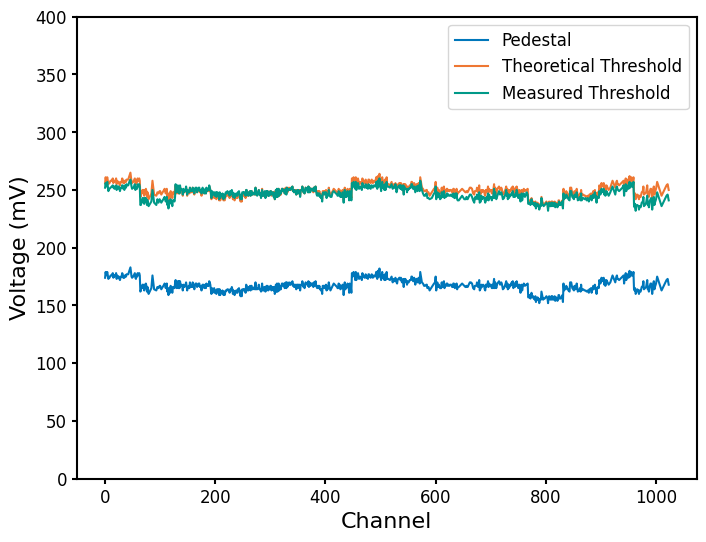

In [5]:
'''-------------------------------VOLTAGE VS CHANNEL PLOT------------------------------'''
logscale = False

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(ch_number, pedestal, color=plot_colors[0], linewidth=1.5, label='Pedestal')
ax.plot(ch_number, absolute_theoretical_threshold, color=plot_colors[1], linewidth=1.5, label='Theoretical Threshold')
ax.plot(ch_number, threshold, color=plot_colors[2], linewidth=1.5, label='Measured Threshold')

ax.legend(loc='upper right')
ax.set_xlabel("Channel")
ax.set_ylabel("Voltage (mV)")

if logscale == True:
    ax.set_yscale("log")

ax.set_ylim(0, 400)

#Show where good VMM Hybrids with no dead channels are
#ax.axvline(128, color=plot_colors[3], linestyle='--')
#ax.axvline(384, color=plot_colors[3], linestyle='--')

fig.savefig(f'plots/png/pedestal_threshold_comparison.png', bbox_inches="tight")
fig.savefig(f'plots/pdf/pedestal_threshold_comparison.pdf', bbox_inches="tight")

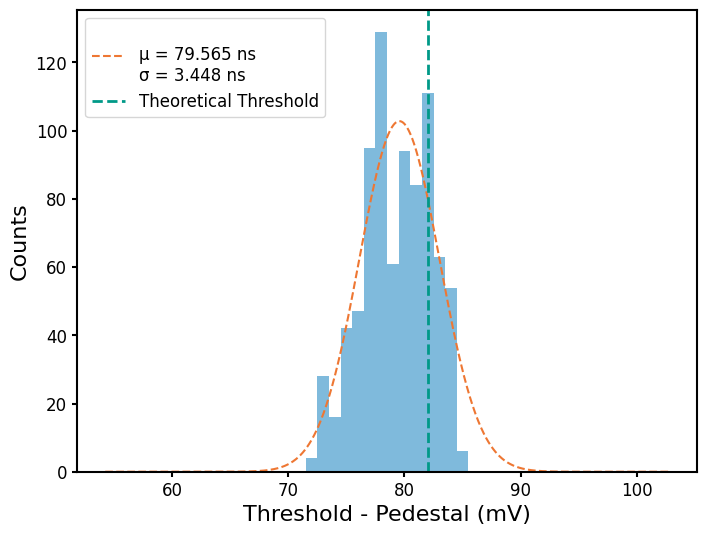

In [6]:
'''-------------------------------THRESHOLD TO PEDESTAL HISTOGRAM------------------------------'''
logscale = False

threshold_to_pedestal = threshold - pedestal
#threshold_to_pedestal = threshold_to_pedestal[(ch_number > 127) & (ch_number < 385)] #to isolate the 2 VMM Hybrids with no dead channels

fig, ax = plt.subplots(figsize=(8, 6))

bins = np.arange(min(threshold_to_pedestal)-0.5, max(threshold_to_pedestal) + 1.5)
counts, bin_edges, patches = ax.hist(threshold_to_pedestal, bins=bins, color=plot_colors[0], linewidth=1.25, alpha=0.5)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=[counts.max(), np.mean(threshold_to_pedestal), np.std(threshold_to_pedestal)])
ampT, meanT, stdT = popt

x_fit = np.linspace(bin_edges[0]-stdT*5, bin_edges[-1]+stdT*5, 1000)
ax.plot(x_fit, gaussian(x_fit, *popt), color=plot_colors[1], linewidth=1.5, linestyle='--', label=f'\nμ = {meanT:.3f} ns\nσ = {stdT:.3f} ns')

ax.axvline(theoretical_threshold, color=plot_colors[2], linestyle='--', label='Theoretical Threshold')

ax.legend(loc='upper left')
ax.set_xlabel("Threshold - Pedestal (mV)")
ax.set_ylabel("Counts")

if logscale == True:
    ax.set_yscale("log")

#ax.set_xlim(75, 95)

fig.savefig(f'plots/png/threshold_to_pedestal_hist.png', bbox_inches="tight")
fig.savefig(f'plots/pdf/threshold_to_pedestal_hist.pdf', bbox_inches="tight")